In [1]:
import pandas as pd
import numpy as np
import re
import string
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import confusion_matrix, classification_report
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("phishing_email.csv")


In [3]:
df.head()

,text_combined,label
0,hpl nom may 25 2001 see attached file hplno 52...,0
1,nom actual vols 24 th forwarded sabrae zajac h...,0
2,enron actuals march 30 april 1 201 estimated a...,0
3,hpl nom may 30 2001 see attached file hplno 53...,0
4,hpl nom june 1 2001 see attached file hplno 60...,0


In [4]:
print(df.columns.tolist())

['text_combined', 'label']


In [5]:
print("Total rows:", len(df))
print("Duplicate rows:", df.duplicated(subset=['text_combined']).sum())
print(df.duplicated(subset=['text_combined', 'label']).sum())

Total rows: 82486
Duplicate rows: 408
408


In [6]:
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'http\S+', '', text)
    text = re.sub(r'\d+', '', text)
    text = text.translate(str.maketrans('', '', string.punctuation))
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df['clean_text'] = df['text_combined'].apply(clean_text)
df = df.dropna(subset=['clean_text', 'label'])
df.head()

,text_combined,label,clean_text
0,hpl nom may 25 2001 see attached file hplno 52...,0,hpl nom may see attached file hplno xls hplno xls
1,nom actual vols 24 th forwarded sabrae zajac h...,0,nom actual vols th forwarded sabrae zajac hou ...
2,enron actuals march 30 april 1 201 estimated a...,0,enron actuals march april estimated actuals ma...
3,hpl nom may 30 2001 see attached file hplno 53...,0,hpl nom may see attached file hplno xls hplno xls
4,hpl nom june 1 2001 see attached file hplno 60...,0,hpl nom june see attached file hplno xls hplno...


In [11]:
print("Before:", len(df))
df = df.drop_duplicates(subset=['clean_text', 'label']).reset_index(drop=True)
print("After:", len(df))
print(df['label'].value_counts())

Before: 80726
After: 80726
label
1    42716
0    38010
Name: count, dtype: int64


In [8]:
tfidf = TfidfVectorizer(max_features=3000)
X = tfidf.fit_transform(df['clean_text']).toarray()
y = df['label'].values
print("X shape:", X.shape)

X shape: (80726, 3000)


In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


In [24]:
from tensorflow.keras.layers import Input
from tensorflow.keras.callbacks import EarlyStopping

model = Sequential([
    Input(shape=(X_train.shape[1],)),
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                      │ (None, 128)                 │         384,128 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_3 (Dropout)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 1)                   │              65 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 392,449 (1.50 MB)

 Trainable params: 392,449 (1.50 MB)

 Non-trainable params: 0 (0.00 B)

In [25]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=15,
    batch_size=32,
    callbacks=[early_stop]
)

Epoch 1/15
2019/2019 ━━━━━━━━━━━━━━━━━━━━ 42s 18ms/step - accuracy: 0.9695 - loss: 0.0883 - val_accuracy: 0.9809 - val_loss: 0.0540
Epoch 2/15
2019/2019 ━━━━━━━━━━━━━━━━━━━━ 36s 18ms/step - accuracy: 0.9856 - loss: 0.0410 - val_accuracy: 0.9826 - val_loss: 0.0510
Epoch 3/15
2019/2019 ━━━━━━━━━━━━━━━━━━━━ 39s 17ms/step - accuracy: 0.9924 - loss: 0.0231 - val_accuracy: 0.9845 - val_loss: 0.0504
Epoch 4/15
2019/2019 ━━━━━━━━━━━━━━━━━━━━ 38s 19ms/step - accuracy: 0.9963 - loss: 0.0124 - val_accuracy: 0.9853 - val_loss: 0.0590
Epoch 5/15
2019/2019 ━━━━━━━━━━━━━━━━━━━━ 39s 19ms/step - accuracy: 0.9980 - loss: 0.0064 - val_accuracy: 0.9845 - val_loss: 0.0696
Epoch 6/15
2019/2019 ━━━━━━━━━━━━━━━━━━━━ 37s 18ms/step - accuracy: 0.9985 - loss: 0.0047 - val_accuracy: 0.9847 - val_loss: 0.0753


In [26]:
loss, acc = model.evaluate(X_test, y_test)
print(f"Test Accuracy: {acc:.4f}")

y_pred = (model.predict(X_test) > 0.5).astype(int)
cm = confusion_matrix(y_test, y_pred)

505/505 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9845 - loss: 0.0504
Test Accuracy: 0.9845
505/505 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step


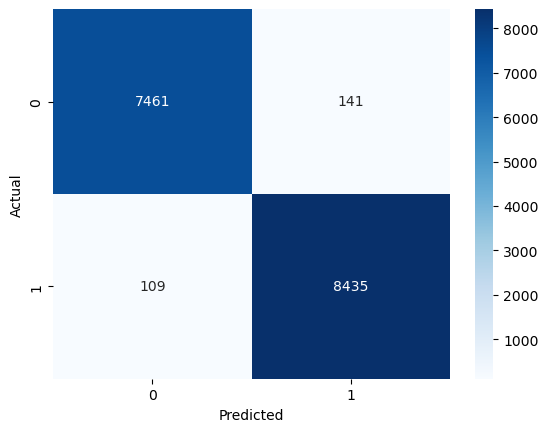

              precision    recall  f1-score   support

           0       0.99      0.98      0.98      7602
           1       0.98      0.99      0.99      8544

    accuracy                           0.98     16146
   macro avg       0.98      0.98      0.98     16146
weighted avg       0.98      0.98      0.98     16146



In [27]:
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()
print(classification_report(y_test, y_pred))

In [28]:
test_samples = [
    "Congratulations! You won a lottery, click here to claim now",
    "Hi team, please find attached the quarterly report for review before Monday's meeting",
    "URGENT: Your bank account has been suspended, verify your details immediately at this link",
    "Can we reschedule our call to 3pm tomorrow instead of 2pm?",
    "You have been selected for a free iPhone giveaway, claim your prize now!!!",
    "Please review the attached invoice and confirm payment by end of week"
]

test_clean = [clean_text(s) for s in test_samples]
test_vec = tfidf.transform(test_clean).toarray()
predictions = model.predict(test_vec)

for text, pred in zip(test_samples, predictions):
    label = "Malicious/Spam" if pred[0] > 0.5 else "Safe/Ham"
    print(f"{label} ({pred[0]:.3f}) --> {text}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step
Malicious/Spam (1.000) --> Congratulations! You won a lottery, click here to claim now
Safe/Ham (0.000) --> Hi team, please find attached the quarterly report for review before Monday's meeting
Malicious/Spam (1.000) --> URGENT: Your bank account has been suspended, verify your details immediately at this link
Safe/Ham (0.001) --> Can we reschedule our call to 3pm tomorrow instead of 2pm?
Malicious/Spam (0.997) --> You have been selected for a free iPhone giveaway, claim your prize now!!!
Malicious/Spam (0.874) --> Please review the attached invoice and confirm payment by end of week


In [30]:
model.save("mal_email_detector.keras")

import joblib
joblib.dump(tfidf, "tfidf_vectorizer.joblib")

['tfidf_vectorizer.joblib']